# Image-to-Image Translation with Pix2Pix: Maps Dataset

**Authors:** Daniel González Filgueira & Yago Estévez Figueiras  
**Course:** Computer Vision II  - Master in Artificial Intelligence   

## Introduction

This notebook presents the development of an image-to-image translation method that, given a geographic label map, provides a realistic satellite image. The core of this project is the implementation of the **Pix2Pix** model, which employs adversarial training to learn a mapping function from an input domain to an output domain. 

Throughout this notebook we will address the different steps in our work, but first a brief summary of our work:

1. Explain our data preprocesing and the preparation of the Dataloaders.
2. Exlain our model architecture and proceed to train different configurations in order to stablish our baseline.
3. In order to improve our model we will apply data augmentation and test different configurations, expecting some improvement.
4. Once we finish our tests, we will change the training procedure and train for longer periods our potential best models (saving them every 50 epochs).
5. Compare the performance of the best model with the baseline.

*Note: To maintain readability and focus on experimentation, most of the complex functions, data loaders, and network architectures are modularized in the `utils.py` file.*

## 1. Setup

First, import the required libraries and utils:

In [1]:
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os
import json
import time
import utils
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else  "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset and DataLoader Initialization

Since the Maps dataset is provided as a single collection of images, we need to dynamically partition it to create different set in order to properly evaluate our models' generalization capabilities.

In this cell, we use PyTorch's `random_split` function to divide the full dataset into three distinct subsets:
- **Training set (80%):** Used to train the Pix2Pix model.
- **Validation set (10%):** Used to monitor performance during training and tune hyperparameters.
- **Testing set (10%):** Kept completely unseen until the final evaluation to measure the ultimate performance.

After splitting, we initialize a `DataLoader` for each subset. The training loader is shuffled to ensure the model does not learn the sequence of the data, while validation and testing loaders remain unshuffled.

In [2]:
# Define the path to the dataset containing all images
DATA_DIR = "./maps"
# Define batch size
BATCH_SIZE = 1
# Define CPU threads to load prepare images while training
NUM_WORKERS = 2

# Load transforms and the complete dataset
transforms = utils.get_transforms()
full_dataset = utils.MapsDataset(root_dir=DATA_DIR, transform=transforms)

# Calculate split sizes (80% train, 10% val, 10% test)
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size   # The remainder goes to test

# Perform the random split (using a manual seed for reproducibility)
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size], 
    generator=generator
)

# Initialize DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)   # We only shuffle the training set
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Total images found: {total_size}")
print(f"Allocated for Training: {len(train_dataset)}")
print(f"Allocated for Validation: {len(val_dataset)}")
print(f"Allocated for Testing: {len(test_dataset)}")

Total images found: 500
Allocated for Training: 400
Allocated for Validation: 50
Allocated for Testing: 50


*Note on DataLoader Parameters:*

* **`BATCH_SIZE=1`:** Prevents GPU Out-Of-Memory (OOM) errors during GAN training. It also improves image generation quality by making batch normalization act as instance normalization, a standard practice in Pix2Pix.

* **`NUM_WORKERS=2`:** Allocates extra CPU threads to load and prepare images in the background while the GPU trains. This prevents data bottlenecks and speeds up the training loop.

## 3. Data Visualization

Before proceeding to the architecture design, it is important to verify that our custom `MapsDataset` and data pipeline are functioning correctly.

With the following code we fetch a single batch from the training loader. Because our `utils.py` applies normalization (scaling pixel values to the range `[-1, 1]`) to prepare the data for the neural network, we must first unnormalize the tensors back to the `[0, 1]` range. We then visualize the paired samples: the geographic label map (our model's input) on the left, and the realistic satellite image (our model's target) on the right.

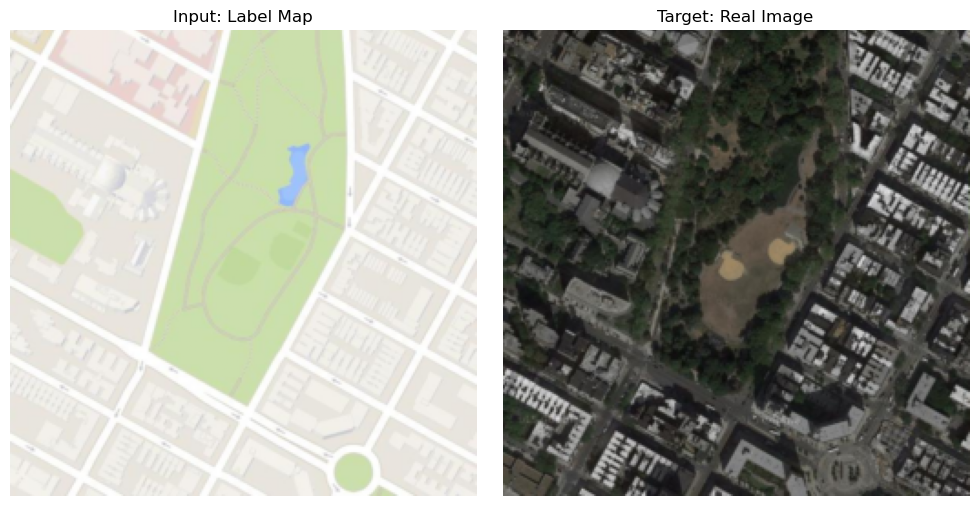

In [3]:
# Fetch one batch of data
input_map, target_image = next(iter(train_loader))

# Unnormalize for visualization (from [-1, 1] to [0, 1])
input_map_viz = utils.unnormalize(input_map[0]).permute(1, 2, 0)
target_image_viz = utils.unnormalize(target_image[0]).permute(1, 2, 0)

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(input_map_viz)
axes[0].set_title("Input: Label Map")
axes[0].axis("off")

axes[1].imshow(target_image_viz)
axes[1].set_title("Target: Real Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4. Model Architecture

In accordance with the Pix2Pix framework, our adversarial setup requires two distinct networks:

1. **Generator (U-Net):** An encoder-decoder architecture that translates the input label map into a realistic image. It uses *skip connections* bypassing the bottleneck to directly feed high-resolution structural information from the encoder directly to the decoder.

2. **Discriminator (PatchGAN):** Unlike standard discriminators that output a single scalar probability for the entire image, the PatchGAN discriminator outputs an $N \times N$ matrix. Each element in this matrix represents the probability of a specific local patch in the image being real or fake. It takes a concatenation of the input map and the image (either real or generated) as its input.

We instantiate both models and send them to the corresponding device.

### U-Net Generator

The generator in a Pix2Pix model translates an input map into a realistic image. To achieve this without losing the fine structural details of the map (like the exact position of streets or buildings), it relies on the **U-Net architecture**.

Our U-Net consists of three main parts:

1. **The Encoder (Downsampling):** A series of Convolutional layers (`UNetDown`) that progressively compress the $256 \times 256$ input image. Each step halves the spatial dimensions (width and height) while doubling the number of feature channels. It extracts high-level semantic context but loses exact spatial information. By the bottom of the "U" (the bottleneck), the image is compressed into a $1 \times 1$ block with 512 channels.

2. **The Decoder (Upsampling):**
   A series of Transposed Convolutional layers (`UNetUp`) that do the exact opposite: they double the spatial dimensions and halve the channels step-by-step, attempting to reconstruct a $256 \times 256$ image from the bottleneck's context.

3. **Skip Connections:**
   If we only used an encoder and a decoder, the model would struggle to draw crisp edges because all spatial resolution was destroyed in the bottleneck. This is solved connecting the layers of the encoder to the corresponding layers of the decoder.
   
   In the code, this happens in `torch.cat((x, skip_input), 1)`. The features from a specific encoder level (e.g., `d6`) are concatenated along the channel axis to the upsampled output of the decoder (e.g., `u1`). This allows the decoder to construct an output image using the compressed information of the bottleneck while also taking into account the fine details from the original image at a specific resolution.

### PatchGAN Discriminator

While a standard GAN discriminator looks at an entire image and outputs a single probability (e.g., "0.9 real" or "0.1 fake"), Pix2Pix introduces the **PatchGAN** architecture. 

A PatchGAN discriminator does not output a single number; instead, it outputs an $N \times N$ matrix (in our specific implementation, a $30 \times 30$ grid). Each individual value in this grid represents the probability of a specific $70 \times 70$ pixel "patch" in the original image being real or fake.

This approach has two massive benefits:

1. **High-Frequency Details:** By forcing the discriminator to focus on local patches rather than the global image, the generator is penalized heavily if it produces blurry textures. It must generate sharp, highly detailed features (like the edges of buildings or trees in our satellite maps) to fool the discriminator patch by patch.

2. **Conditional Input:** The `forward` method concatenates the `condition` (the label map) and the `image` (the generated satellite image). This ensures the discriminator asks two questions simultaneously: *"Does this patch look like a real satellite photo?"* and *"Does this patch strictly follow the layout dictated by the label map?"*

**Data Flow:**
The input starts as a 6-channel tensor (3 map channels + 3 image channels). It passes through three `stride=2` convolutional blocks, halving the spatial resolution each time ($256 \to 128 \to 64 \to 32$). The final two layers use `stride=1` to maintain the patch structure, resulting in the final $1 \times 30 \times 30$ prediction map.

**Important note:**

It is important to clarify that the network does not physically crop the input image into isolated, non-overlapping squares. Instead, it processes the image as a fully convolutional network, acting like a sliding window.

Each individual value in the final 30x30 output matrix is the result of sequential convolutional filters. If we trace the mathematical operations backward from a single output value through the network layers, we find that it is influenced by a specific 70x70 pixel region of the original 256x256 input image. This area of influence is known as the **Receptive Field**.

Because the receptive fields cover 70x70 pixels but are mapped to a dense 30x30 output grid, these evaluated "patches" **overlap**. This overlapping is a desirable feature: it allows the discriminator to evaluate textures and structures smoothly and continuously across the image, preventing the generator from creating artificial seams or boundaries between adjacent regions.

In [4]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

Generator and Discriminator successfully initialized and moved to device.


## 5. Training the Pix2Pix Model

To train our GAN we must first define the loss functions and optimizers, and then run a two-phase training loop.

**1. Setup (Losses & Optimizers):**

* **Adversarial Loss (`BCEWithLogitsLoss`):** Used by the discriminator to classify patches as Real (1) or Fake (0), and by the generator to measure how successfully it fooled the discriminator. We specifically choose `BCEWithLogitsLoss` over the standard `BCELoss` for numerical stability. By combining the Sigmoid activation and the Binary Cross Entropy into a single mathematical operation, it prevents numerical underflow/overflow.

* **Pixel-wise Loss (`L1Loss`):** Compares the generated image directly against the real satellite image pixel by pixel. This ensures the structural layout of the map is respected. The final Generator loss heavily favors this L1 loss (with a weight of $\lambda = 100$) to prevent hallucinations.

* **Optimizers:** We use **Adam** with a learning rate of $0.0002$.

**2. The Training Loop:**

In each iteration, we process a single batch through two distinct phases:

* **Phase 1: Train the Discriminator.** We feed it a real image and then a generated (fake) image. We calculate the loss for both and update its weights.

* **Phase 2: Train the Generator.** We generate a fake image and ask the Discriminator to evaluate it. The Generator computes its loss as if the target label were 1 (because it wants to fool the Discriminator). We add the L1 loss to ensure the generated image matches the map, and update the Generator's weights to make it a better.



## 6. Model evaluation
 As for the evaluation of our models, we will compute the pixel-wise loss for each of them in the test set. Howewver this is not a reliable result for the joint statistics of the resulting image, so we will run an inference for each model on the test set and visually compare the resulting images. All of this tets will be exported as .html files and can be found in the project folder.

### Find our baseline (Efect of the penalization term $\lambda$).

As a first approach to develop our baseline model, we will train different configurations, according to its $\lambda$ parameter.

To reduce computational cost and time we will use earlystopping with patience of 20 epochs and reduce on plateau to reduce the learning rate. This is not the ideal scenario as during GAN's training, the Generator loss (our traking metric) oscilates as a result of the adversarial training nature. However this first approach is just to see the effect of the penalization term and for the last configurations we will use another training methodology, with periodically saves, a monitor for the best G loss model and a linearly decreasing learning rate every 100 epochs.

To perform this test, we developed the function `train_pix2pix_v2` that implement checkpoints during training, saving the best model weights.

### Test 1 ($\lambda$ = 100)

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1" 
MODEL_NAME = "test_1"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)

print("Baseline training complete!")



In [ ]:
# Save training history
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

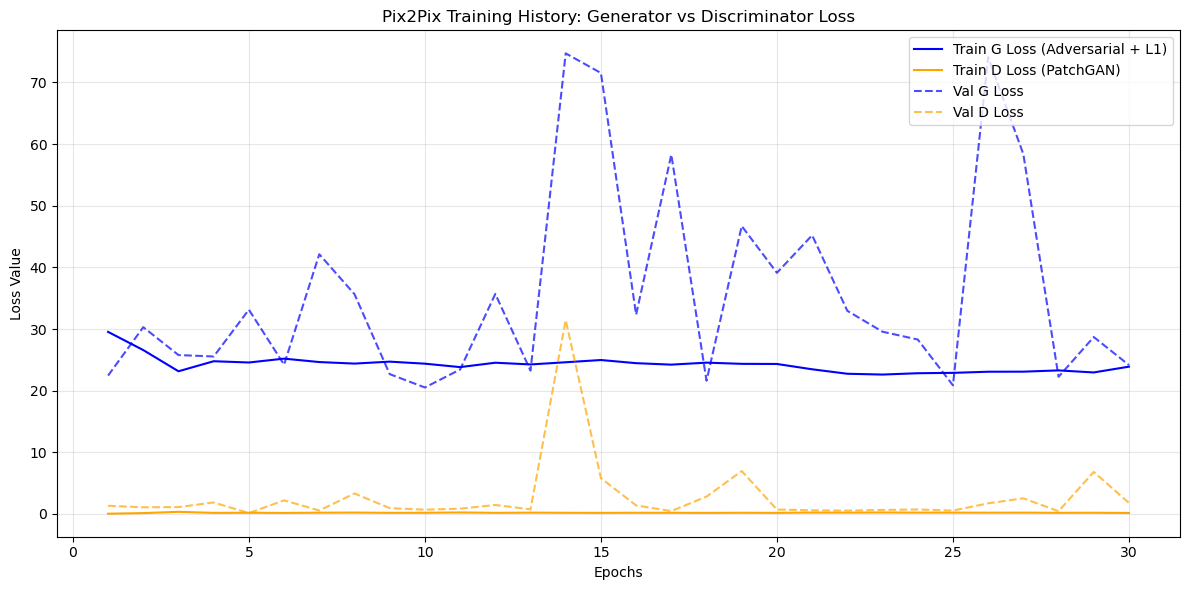

In [7]:
# Load history and plot training results
with open("trained_models/arch_1/model_1/history_test_1.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 2 ($\lambda$ = 200)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 200
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1" 
MODEL_NAME = "test_2"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)

print("Baseline training complete!")



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

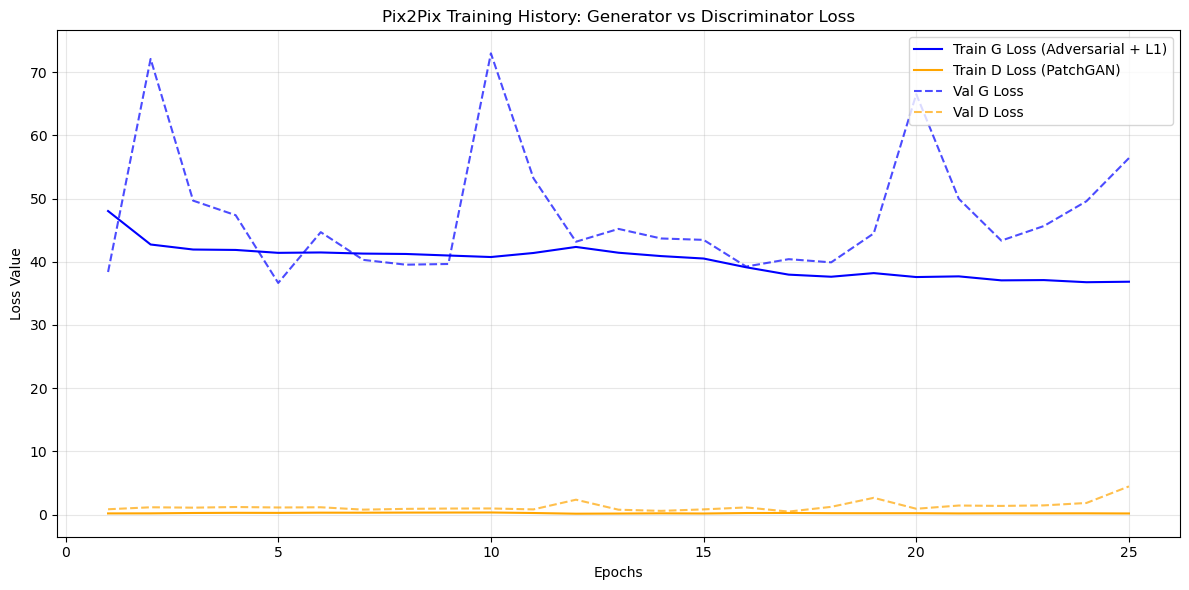

In [8]:
with open("trained_models/arch_1/model_1/history_test_2.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 3 ($\lambda$ = 300)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 300
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1" 
MODEL_NAME = "test_3"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)

print("Baseline training complete!")

In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

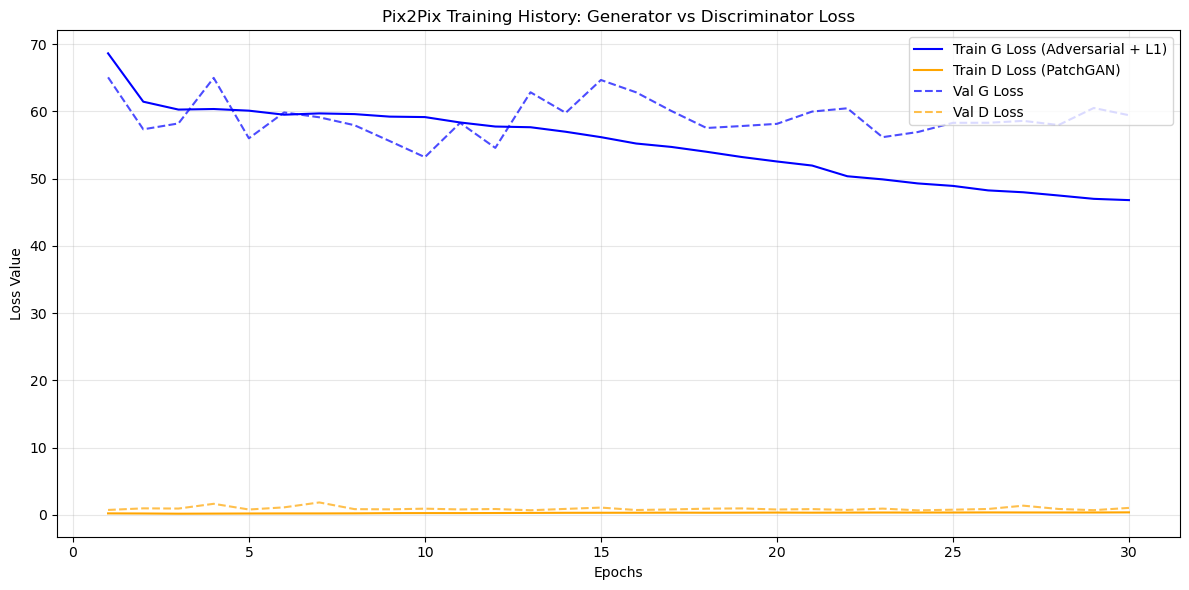

In [9]:
with open("trained_models/arch_1/model_1/history_test_3.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

## Improvements

As a first try to improve our results we included data Augmentation in the training set:
- vertical flips
- horizontal flips
- random rotations

In [ ]:
# Define the path to the dataset containing all images
DATA_DIR = "./maps"
# Define batch size
BATCH_SIZE = 1
# Define CPU threads to load prepare images while training
NUM_WORKERS = 2

# Load transforms 
transforms = utils.get_transforms()

# Load 2 intances, one with augmentation for training and other without for validation and test

train_full_dataset = utils.MapsDataset(root_dir=DATA_DIR, transform=transforms, augment=True)
val_test_full_dataset = utils.MapsDataset(root_dir=DATA_DIR, transform=transforms, augment=False)

# Ensure same indexes for both
total_size = len(train_full_dataset)
indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42)).tolist()

# Split limits
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)

# Split
train_indices = indices[:train_size]
val_indices = indices[train_size : train_size + val_size]
test_indices = indices[train_size + val_size :]

# Create the subsets
train_dataset = torch.utils.data.Subset(train_full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(val_test_full_dataset, val_indices)
test_dataset = torch.utils.data.Subset(val_test_full_dataset, test_indices)

# Init dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Total images found: {total_size}")
print(f"Allocated for Training (Augmented): {len(train_dataset)}")
print(f"Allocated for Validation (Deterministic): {len(val_dataset)}")
print(f"Allocated for Testing (Deterministic): {len(test_dataset)}")

### Test 1 ($\lambda$ = 300)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 300
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1_augmented" 
MODEL_NAME = "test_1"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

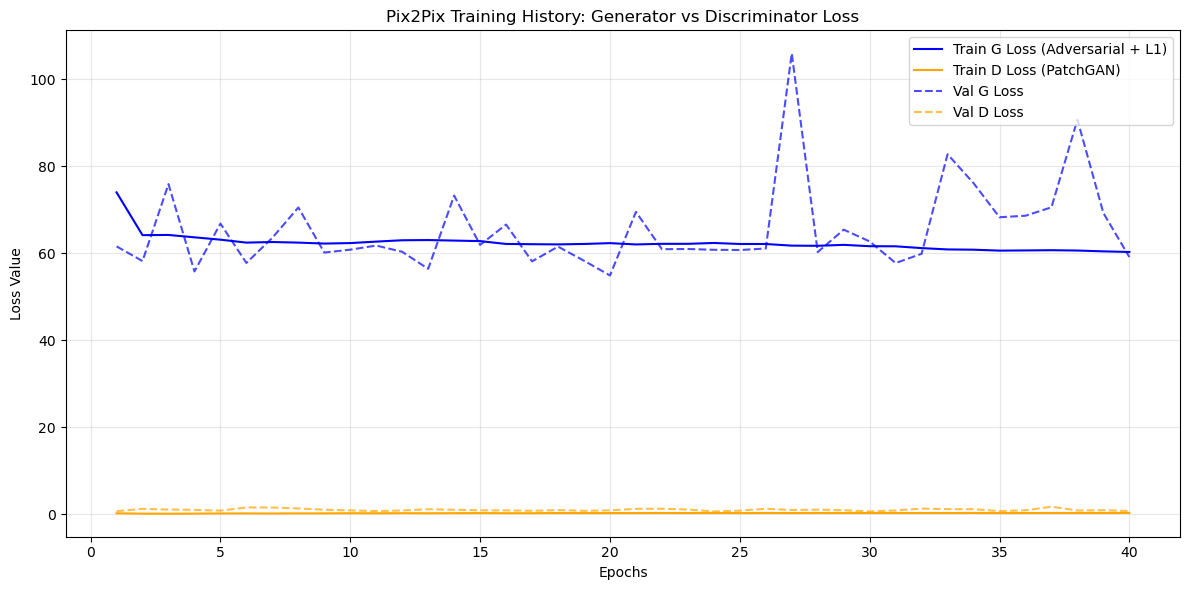

In [14]:
with open("trained_models/arch_1/model_1_augmented/history_test_1.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 2 ($\lambda$ = 200)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 200
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1_augmented" 
MODEL_NAME = "test_2"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

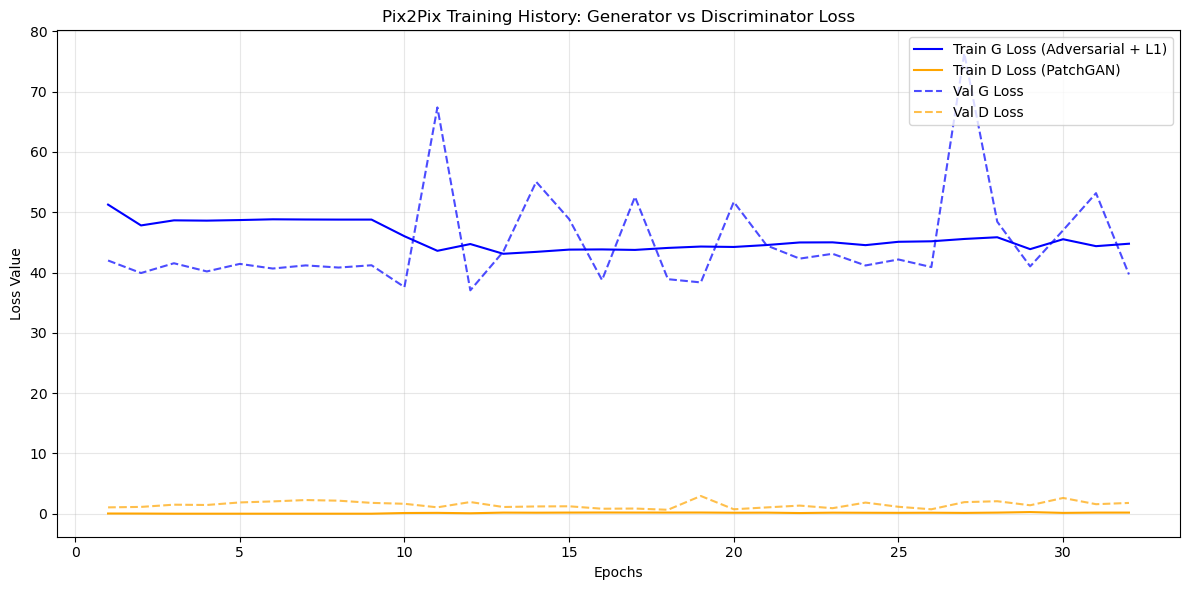

In [13]:
with open("trained_models/arch_1/model_1_augmented/history_test_2.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 3 ($\lambda$ = 100)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1_augmented" 
MODEL_NAME = "test_3"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

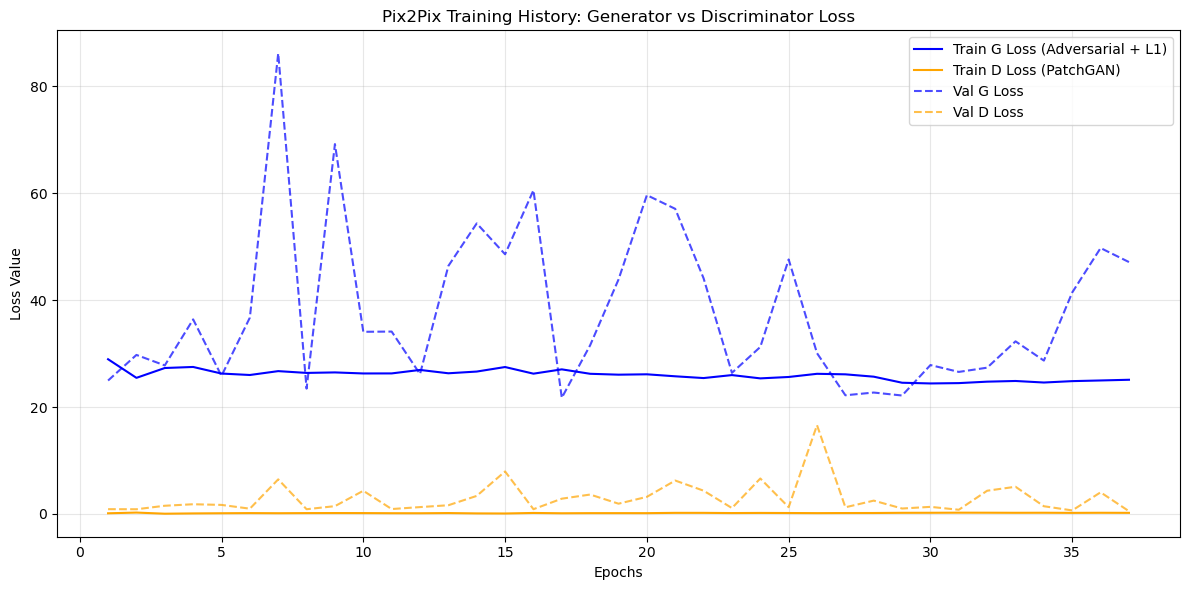

In [12]:
with open("trained_models/arch_1/model_1_augmented/history_test_3.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 4 ($\lambda$ = 500)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 500
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1_augmented" 
MODEL_NAME = "test_4"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

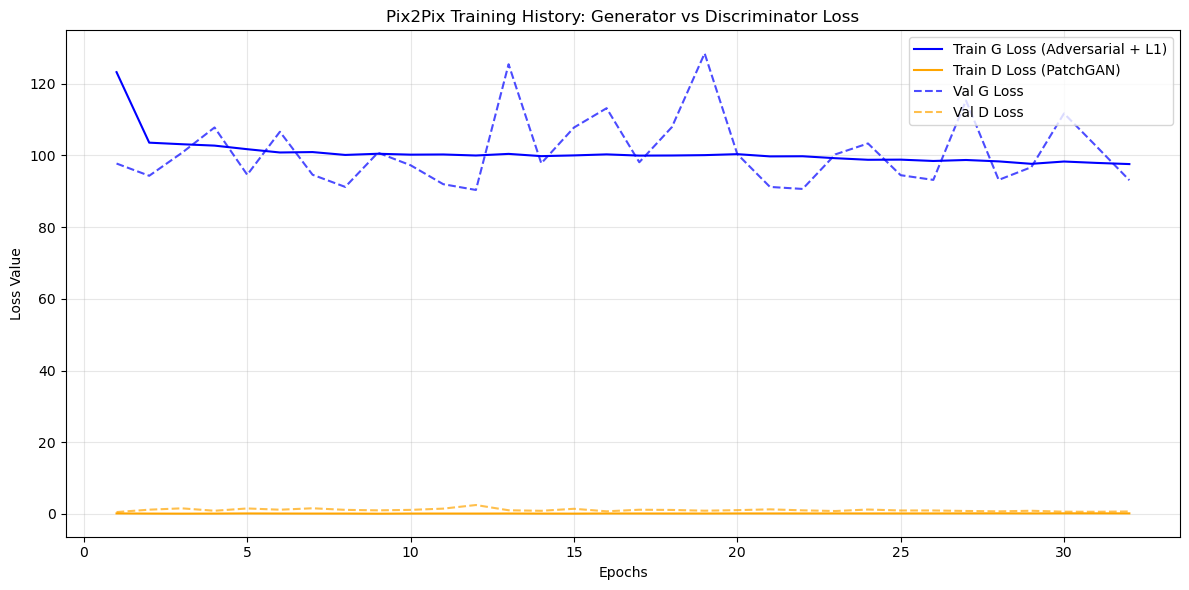

In [11]:
with open("trained_models/arch_1/model_1_augmented/history_test_4.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 5 ($\lambda$ = 750)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 750
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1_augmented" 
MODEL_NAME = "test_5"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

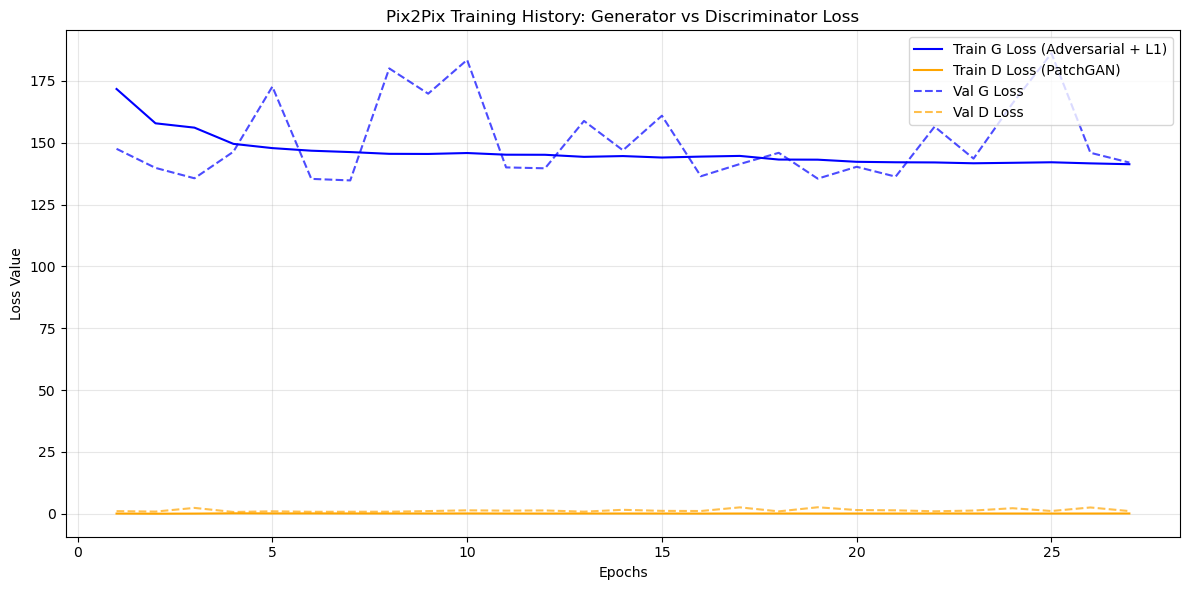

In [10]:
with open("trained_models/arch_1/model_1_augmented/history_test_5.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Test 6 ($\lambda$ = 1000)

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 1000
EPOCHS = 100
PATIENCE = 20
OUTPUT_DIR = "trained_models/arch_1/model_1_augmented" 
MODEL_NAME = "test_6"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v2(
    generator=generator, 
    discriminator=discriminator, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device,
    criterion_GAN=criterion_GAN,
    criterion_pixelwise=criterion_pixelwise,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    epochs=EPOCHS,
    lambda_l1=LAMBDA_L1,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME
)



In [ ]:
history_path = os.path.join(OUTPUT_DIR, f"history_{MODEL_NAME}.json")

with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"Histoy saved in: {history_path}")

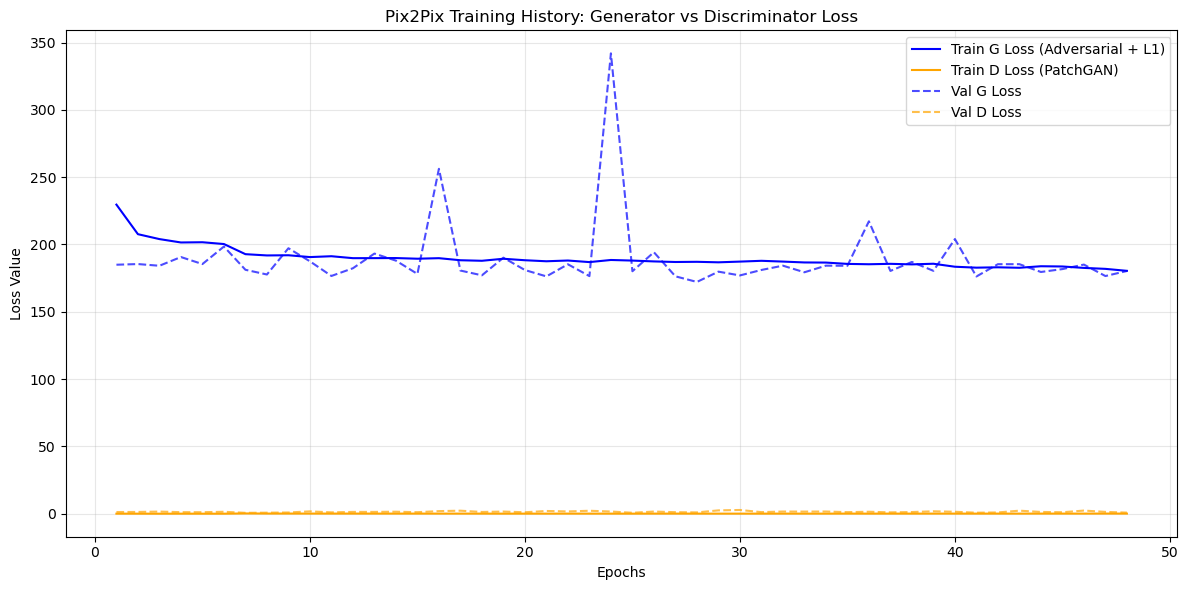

In [15]:
with open("trained_models/arch_1/model_1_augmented/history_test_6.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Important
All the previous models were trained using earlystopping with low patience values (20 epochs), the main reason was just to retrieve the best model according to the L1 val G loss, however due to the Gans alternative nature this may not be the model that outputs the best images. Despite this, the trained models serve us as a way to see the effect of the lambda value.

As a next step we will use the configuration with lambda = 300, and train it for 500 epochs, saving the model after every 50 epochs and the best val G model to set a final comparison on the generated images without earlystopping. As i mentioned, the previous tests served us to manually tune the lambda value. 

Also we will avoid the LR reduce on plateau that we implemented previouslly and proceed to use an scheduled reduction on the LR every 100 epochs by a factor of 0.7. 

With all this in mind we developed the train_pix2pix_v3() function

### $\lambda = 300$

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 300
EPOCHS = 500
LR_STEP = 100
SAVE_STEP = 50
OUTPUT_DIR = "trained_models/arch_1/model_1_lambda_300_long" 
MODEL_NAME = "lambda_300"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v3(
    generator = generator, 
    discriminator = discriminator, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    device = device, 
    criterion_GAN = criterion_GAN,
    criterion_pixelwise = criterion_pixelwise,
    optimizer_G = optimizer_G, 
    optimizer_D = optimizer_D,
    epochs = EPOCHS, 
    lambda_l1 = LAMBDA_L1, 
    step_size = LR_STEP, 
    save_step = SAVE_STEP, 
    output_dir = OUTPUT_DIR, 
    model_name = MODEL_NAME
)



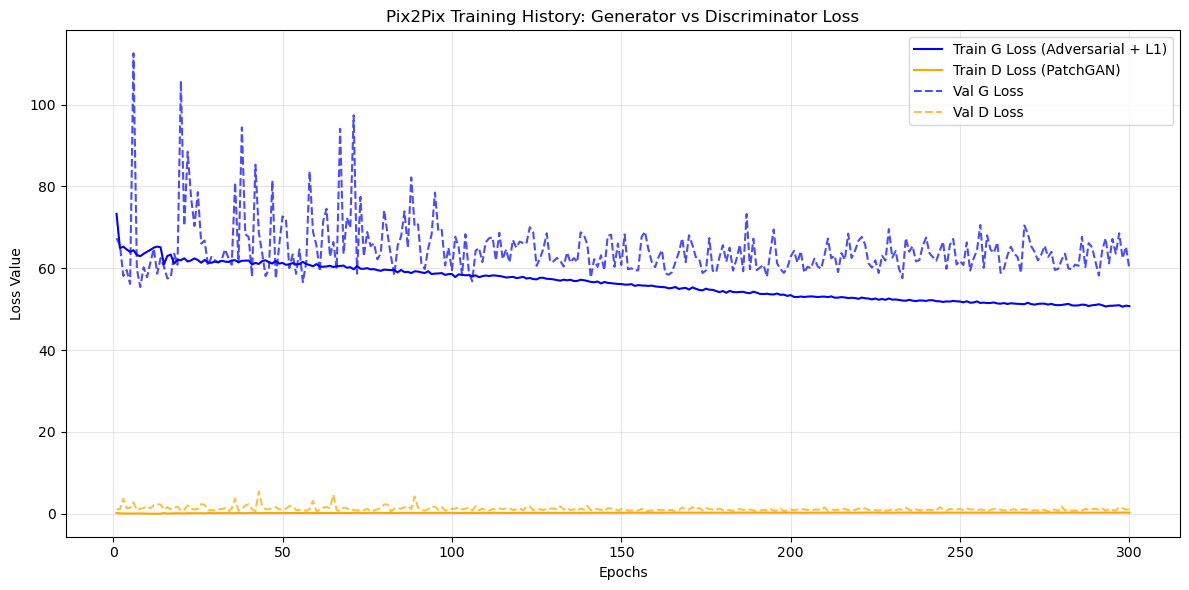

In [16]:
with open("trained_models/arch_1/model_1_lambda_300_long/history_lambda_300.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### Note:

If we lookn this plot, we see that the combination of a decreasing LR and significantlly more epochs to train reduce the oscilations.

The results of this models generated artifacts in the  image, this may be a response of the model to a strict labda value, that forces it to mantain the shape of the map. We will test other values to give the model more freedom if $\lambda$ is lower or increasing it to seee if more artifacts appear.


### $\lambda = 100$

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100
EPOCHS = 500
LR_STEP = 100
SAVE_STEP = 50
OUTPUT_DIR = "trained_models/arch_1/model_1_lambda_100_long" 
MODEL_NAME = "lambda_100"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v3(
    generator = generator, 
    discriminator = discriminator, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    device = device, 
    criterion_GAN = criterion_GAN,
    criterion_pixelwise = criterion_pixelwise,
    optimizer_G = optimizer_G, 
    optimizer_D = optimizer_D,
    epochs = EPOCHS, 
    lambda_l1 = LAMBDA_L1, 
    step_size = LR_STEP, 
    save_step = SAVE_STEP, 
    output_dir = OUTPUT_DIR, 
    model_name = MODEL_NAME
)



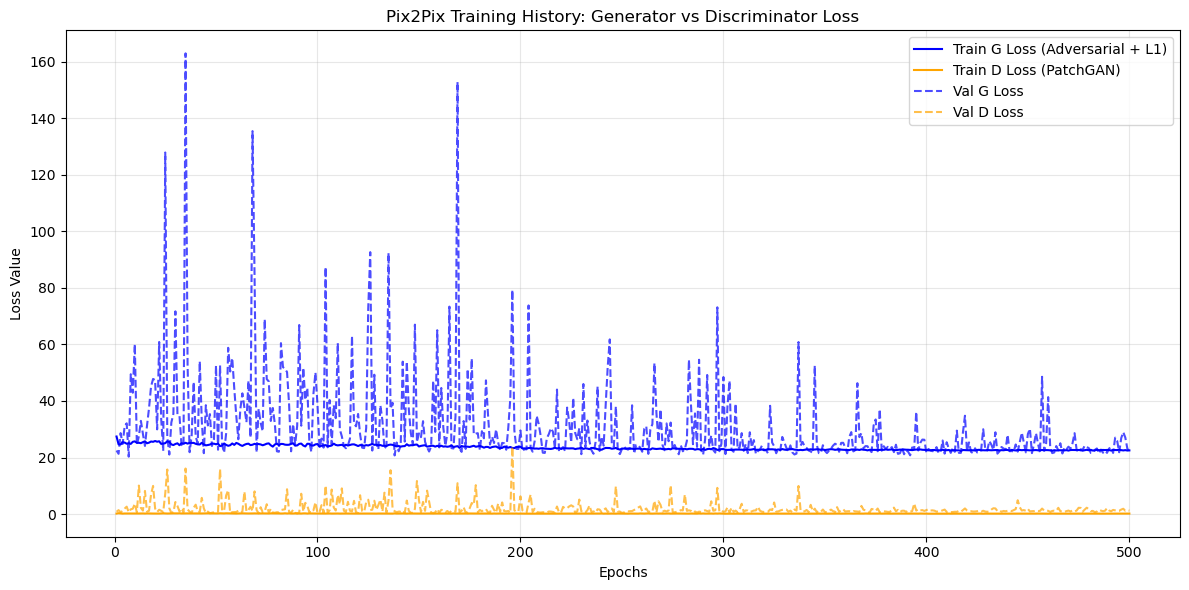

In [17]:
with open("trained_models/arch_1/model_1_lambda_100_long/history_lambda_100.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

### $\lambda = 500$

In [ ]:
# Initialize Generator and Discriminator
generator = utils.GeneratorUNet(in_channels=3, out_channels=3)   # from RGB labels to RGB real image
discriminator = utils.Discriminator(in_channels=3)   # receives RGB image (real or generated)

# Send models to the configured device
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Generator and Discriminator successfully initialized and moved to device.")

In [ ]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# SETUP: HYPERPARAMETERS, LOSSES & OPTIMIZERS
# ==========================================
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 500
EPOCHS = 500
LR_STEP = 100
SAVE_STEP = 50
OUTPUT_DIR = "trained_models/arch_1/model_1_lambda_500_long" 
MODEL_NAME = "lambda_500"
# Loss Functions
criterion_GAN = nn.BCEWithLogitsLoss().to(device) # Adversarial Loss
criterion_pixelwise = nn.L1Loss().to(device)      # Pixel-wise Loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

# ==========================================
# EXECUTE TRAINING (Baseline)
# ==========================================
generator, discriminator, history = utils.train_pix2pix_v3(
    generator = generator, 
    discriminator = discriminator, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    device = device, 
    criterion_GAN = criterion_GAN,
    criterion_pixelwise = criterion_pixelwise,
    optimizer_G = optimizer_G, 
    optimizer_D = optimizer_D,
    epochs = EPOCHS, 
    lambda_l1 = LAMBDA_L1, 
    step_size = LR_STEP, 
    save_step = SAVE_STEP, 
    output_dir = OUTPUT_DIR, 
    model_name = MODEL_NAME
)



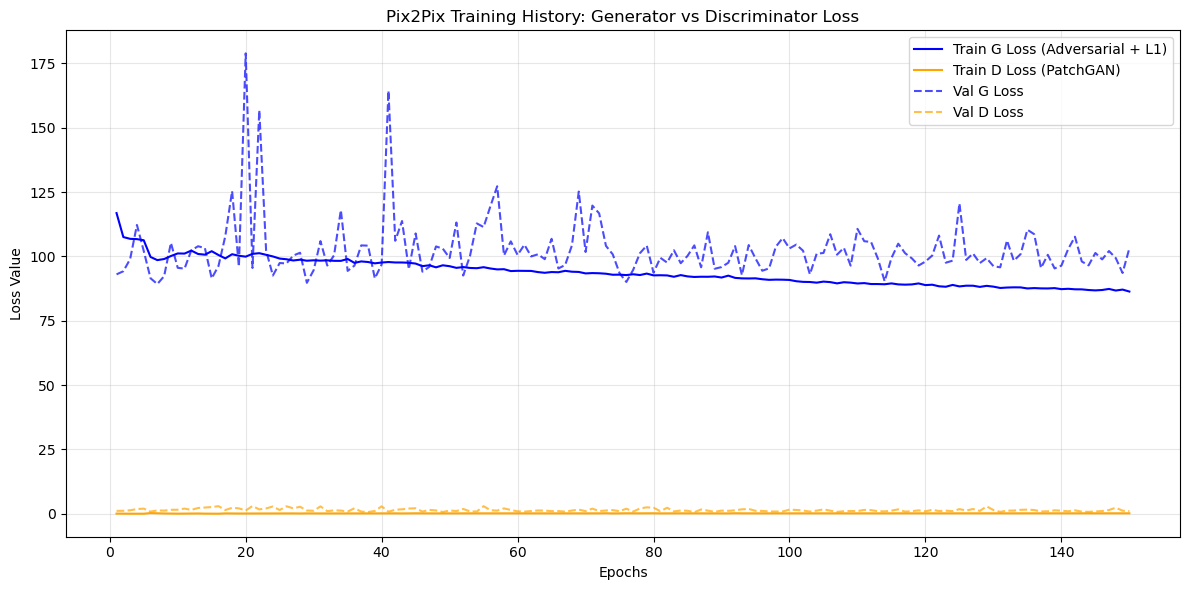

In [18]:
with open("trained_models/arch_1/model_1_lambda_500_long/history_lambda_500.json", 'r') as f:
    history_from_json = json.load(f)


utils.plot_training_history(history_from_json)

##  Model Evaluation and Visualization

Once the training loop is complete and we have verified the loss curves, the final and most intuitive test for an image-to-image translation model like Pix2Pix is qualitative visual inspection. 

With this in mind and due to the number of models and the size of them, we run a benchmark on each and every one of them and later export the results to  .html files, that can be provided if needed.